<a href="https://colab.research.google.com/github/pedrosampaiom2007-gif/cp1-Andre/blob/main/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

## A partir daqui, o trabalho é da equipe

DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Desenvolva aqui o DESAFIO 1

In [ ]:
dados = pd.DataFrame(registros)  # reconstrói do zero, sem renomes acumulados


In [ ]:
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
dados.shape

(336, 11)

In [ ]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


Data: dat_referencia, Hora:din_atualizacao, Área de carga: cod_carga,Valor de carga: val_cargaglobal

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# Desenvolva aqui o DESAFIO 2

In [ ]:
dados = dados.rename(columns={
    'dat_referencia': 'Data',
    'din_referenciautc': 'Hora',   # decidam: essa é a que varia de fato a cada 30 min
    'cod_areacarga': 'Area_Carga',
    'val_cargaglobal': 'Valor_Carga'
})

In [ ]:

dados['Data'] = pd.to_datetime(dados['Data'])
dados['Hora'] = pd.to_datetime(dados['Hora'])

In [ ]:
print(dados['Data'].dtype)
print(dados['Hora'].dtype)

datetime64[ns]
datetime64[ns, UTC]


In [ ]:
necessario = dados[['Data', 'Hora', 'Area_Carga', 'Valor_Carga']].copy()

### Decisões de tratamento — Desafio 2

- Colunas renomeadas para nomes mais simples: `Data`, `Hora`, `Area_Carga`, `Valor_Carga`.
- Hora vem de `din_referenciautc` (varia a cada 30 min), não de `din_atualizacao` (só timestamp de atualização do registro).
- Sem valores ausentes.
- `Valor_Carga` já era numérico (float64).
- `Data` e `Hora` convertidas de texto para `datetime` com `pd.to_datetime()`.
- `necessario` mantém só as colunas relevantes pra análise.

In [ ]:
dados.isnull().sum()

,0
Area_Carga,0
din_atualizacao,0
Data,0
Hora,0
Valor_Carga,0
val_cargaglobalcons,0
val_cargaglobalsmmgd,0
val_cargasupervisionada,0
val_carganaosupervisionada,0
val_cargammgd,0


In [ ]:
dados['Valor_Carga'].dtype

dtype('float64')

In [ ]:
dados['Data'].dtype
dados['Hora'].dtype

datetime64[ns, UTC]

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
carga_minima = dados['Valor_Carga'].min()
carga_maxima = dados['Valor_Carga'].max()
print(f"a carga mínima é:", carga_minima, "a carga máxima é:",  carga_maxima)

a carga mínima é: 12139.253 a carga máxima é: 23185.312


In [ ]:
carga_media = dados['Valor_Carga'].mean()
print(f"a carga média é:", carga_media)

a carga média é: 17870.828980654762


In [ ]:
mediana= dados['Valor_Carga'].median()
print(f"a mediana é:", mediana)

a mediana é: 18199.1285


In [ ]:
amplitude = carga_maxima - carga_minima
print(f"a amplitude é:", amplitude)

a amplitude é: 11046.059000000001


In [ ]:
medições = dados['Valor_Carga'].count()
print(f"a quantidade de medições é:", medições)

a quantidade de medições é: 336


O valor máximo (23185,312) não está muito distante do comportamento médio da série. A diferença entre o máximo e a média (≈5314,48) é semelhante à diferença entre a média e o mínimo (≈5731,58), o que indica uma variação equilibrada em torno da média, e não uma concentração de valores baixos com um pico isolado no topo. Além disso, a proximidade entre média (17870,83) e mediana (18199,13) reforça que a distribuição é aproximadamente simétrica, sem indícios de outliers puxando os indicadores para cima. Portanto, o valor máximo representa um comportamento dentro da variação normal da carga elétrica medida, não um ponto discrepante

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4

In [ ]:
limiar_alta_demanda = carga_maxima * 0.90

print("Limiar de alta demanda:", limiar_alta_demanda)

Limiar de alta demanda: 20866.7808


In [ ]:
alta_demanda = necessario[
    necessario["Valor_Carga"] > limiar_alta_demanda
].copy()

print("\nDataFrame de alta demanda:")
display(alta_demanda)


DataFrame de alta demanda:


,Data,Hora,Area_Carga,Valor_Carga
35,2025-08-01,2025-08-01 21:00:00+00:00,SP,21088.959
36,2025-08-01,2025-08-01 21:30:00+00:00,SP,22398.360
37,2025-08-01,2025-08-01 22:00:00+00:00,SP,23185.312
38,2025-08-01,2025-08-01 22:30:00+00:00,SP,22903.314
39,2025-08-01,2025-08-01 23:00:00+00:00,SP,22358.701
40,2025-08-01,2025-08-01 23:30:00+00:00,SP,21697.979
41,2025-08-01,2025-08-02 00:00:00+00:00,SP,21385.326
42,2025-08-01,2025-08-02 00:30:00+00:00,SP,20919.314
84,2025-08-02,2025-08-02 21:30:00+00:00,SP,20983.484
85,2025-08-02,2025-08-02 22:00:00+00:00,SP,21202.566


In [ ]:
quantidade_alta_demanda = alta_demanda["Valor_Carga"].count()

print("\nQuantidade de registros de alta demanda:",
      quantidade_alta_demanda)


Quantidade de registros de alta demanda: 50


In [ ]:
percentual_alta_demanda = (
    quantidade_alta_demanda / medições
) * 100

print("Percentual de alta demanda:",
      f"{percentual_alta_demanda:.2f}%")

Percentual de alta demanda: 14.88%


In [ ]:
maior_carga = alta_demanda["Valor_Carga"].max()

print("Maior valor de carga:", maior_carga)

Maior valor de carga: 23185.312


In [ ]:
indice_pico = alta_demanda["Valor_Carga"].idxmax()

data_pico = alta_demanda.loc[indice_pico, "Data"]
hora_pico = alta_demanda.loc[indice_pico, "Hora"]

print("Data do pico:", data_pico)
print("Horário do pico:", hora_pico)

Data do pico: 2025-08-01 00:00:00
Horário do pico: 2025-08-01 22:00:00+00:00


In [ ]:
# Conclusão
print("\nConclusão:")
print(
    f"Os períodos próximos ao pico representam uma parcela "
    f"{'grande' if percentual_alta_demanda >= 25 else 'pequena'} "
    f"do período analisado, correspondendo a "
    f"{percentual_alta_demanda:.2f}% das {medições} medições."
)


Conclusão:
Os períodos próximos ao pico representam uma parcela pequena do período analisado, correspondendo a 14.88% das 336 medições.


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Desenvolva aqui o DESAFIO 5

# 1. Critério escolhido: Registros com Valor_Carga abaixo da média

print("Critério escolhido: carga abaixo da média")
print("Carga média:", carga_media)

abaixo_da_media = necessario[
    necessario["Valor_Carga"] < carga_media
].copy()

print("\nDataFrame com carga abaixo da média:")
display(abaixo_da_media)


# 2. Quantidade de registros, percentual e comparações
quantidade_abaixo_media = abaixo_da_media["Valor_Carga"].count()

print("\nQuantidade de registros abaixo da média:",
      quantidade_abaixo_media)

percentual_abaixo_media = (
    quantidade_abaixo_media / medições
) * 100

print("Percentual abaixo da média:",
      f"{percentual_abaixo_media:.2f}%")

print("\n--- Comparação ---")

print(
    f"Alta demanda: {quantidade_alta_demanda} registros "
    f"({percentual_alta_demanda:.2f}%)"
)

print(
    f"Abaixo da média: {quantidade_abaixo_media} registros "
    f"({percentual_abaixo_media:.2f}%)"
)

print("\nConclusão:")

if quantidade_abaixo_media > quantidade_alta_demanda:
    print(
        "O conjunto de registros abaixo da média é maior "
        "do que o conjunto de alta demanda."
    )
else:
    print(
        "O conjunto de registros de alta demanda é maior "
        "do que o conjunto abaixo da média."
    )

Critério escolhido: carga abaixo da média
Carga média: 17870.828980654762

DataFrame com carga abaixo da média:


,Data,Hora,Area_Carga,Valor_Carga
0,2025-08-01,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01,2025-08-01 05:30:00+00:00,SP,13838.488
...,...,...,...,...
298,2025-08-07,2025-08-07 08:30:00+00:00,SP,14908.752
299,2025-08-07,2025-08-07 09:00:00+00:00,SP,15844.801
300,2025-08-07,2025-08-07 09:30:00+00:00,SP,17206.496
301,2025-08-07,2025-08-07 10:00:00+00:00,SP,17379.400



Quantidade de registros abaixo da média: 152
Percentual abaixo da média: 45.24%

--- Comparação ---
Alta demanda: 50 registros (14.88%)
Abaixo da média: 152 registros (45.24%)

Conclusão:
O conjunto de registros abaixo da média é maior do que o conjunto de alta demanda.


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

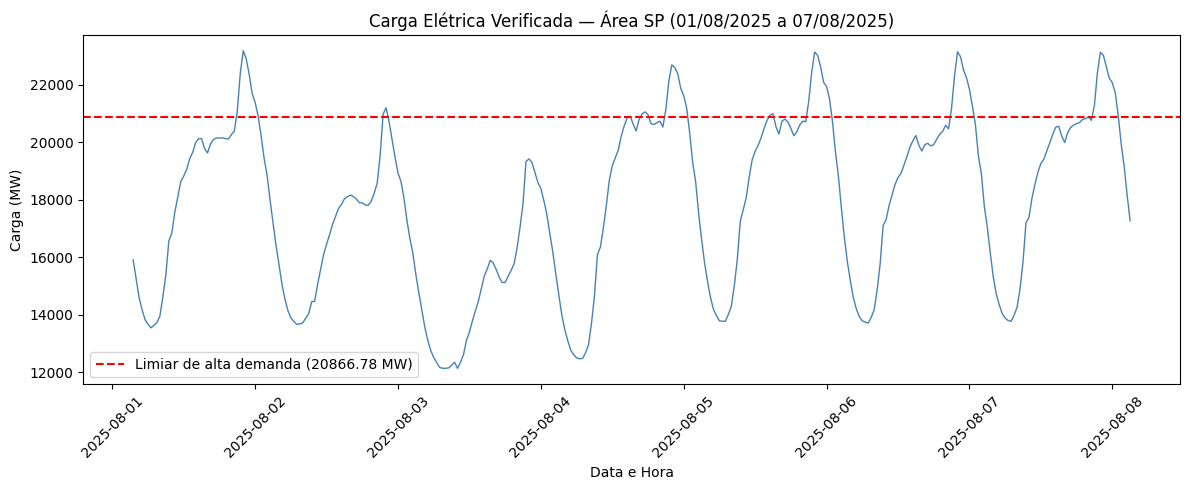

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(necessario['Hora'], necessario['Valor_Carga'], color='steelblue', linewidth=1)
plt.axhline(limiar_alta_demanda, color='red', linestyle='--',
            label=f'Limiar de alta demanda ({limiar_alta_demanda:.2f} MW)')
plt.title('Carga Elétrica Verificada — Área SP (01/08/2025 a 07/08/2025)')
plt.xlabel('Data e Hora')
plt.ylabel('Carga (MW)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(
    "Interpretação: a carga apresenta um padrão cíclico ao longo dos dias, "
    "com subidas e descidas que se repetem diariamente. Os trechos acima da "
    "linha vermelha correspondem aos registros de alta demanda identificados "
    "no Desafio 4, concentrados em horários específicos e não distribuídos "
    "uniformemente ao longo do período."
)

Interpretação: a carga apresenta um padrão cíclico ao longo dos dias, com subidas e descidas que se repetem diariamente. Os trechos acima da linha vermelha correspondem aos registros de alta demanda identificados no Desafio 4, concentrados em horários específicos e não distribuídos uniformemente ao longo do período.


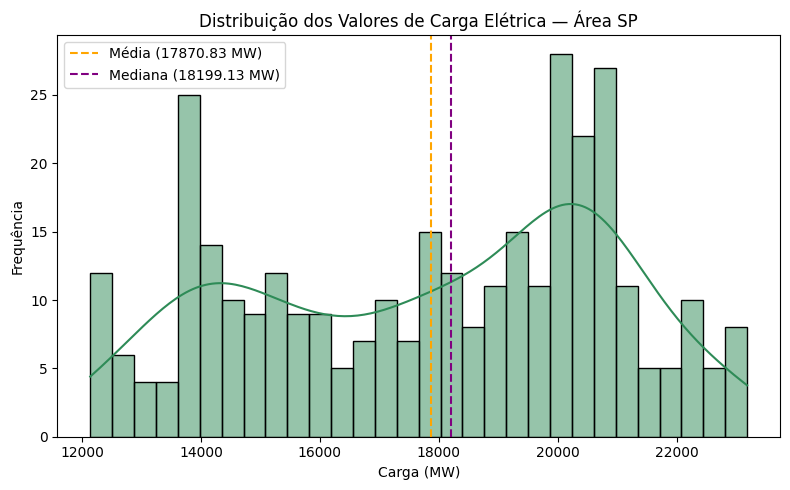

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(necessario['Valor_Carga'], bins=30, kde=True, color='seagreen')
plt.axvline(carga_media, color='orange', linestyle='--', label=f'Média ({carga_media:.2f} MW)')
plt.axvline(mediana, color='purple', linestyle='--', label=f'Mediana ({mediana:.2f} MW)')
plt.title('Distribuição dos Valores de Carga Elétrica — Área SP')
plt.xlabel('Carga (MW)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(
    "Interpretação: a distribuição da carga é aproximadamente simétrica, "
    "com média e mediana próximas, o que confirma o que já havia sido "
    "observado no Desafio 3 — não há concentração forte de valores extremos "
    "puxando a distribuição para um dos lados."
)

Interpretação: a distribuição da carga é aproximadamente simétrica, com média e mediana próximas, o que confirma o que já havia sido observado no Desafio 3 — não há concentração forte de valores extremos puxando a distribuição para um dos lados.


## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
regiao_analisada = "SP - São Paulo"
periodo_analisado = "01/08/2025 a 07/08/2025"

In [ ]:
momento_pico = f"{data_pico} às {hora_pico}"
print("Momento do pico:", momento_pico)

Momento do pico: 2025-08-01 00:00:00 às 2025-08-01 22:00:00+00:00


In [ ]:
resultado_segundo_criterio = (
    f"{quantidade_abaixo_media} registros abaixo da média "
    f"({percentual_abaixo_media:.2f}%)"
)
print("Segundo critério:", resultado_segundo_criterio)

Segundo critério: 152 registros abaixo da média (45.24%)


In [ ]:
resumo_resultados = f'''
Região analisada: {regiao_analisada}
Período analisado: {periodo_analisado}
Quantidade de registros: {medições}
Carga mínima: {carga_minima:.2f} MW
Carga máxima: {carga_maxima:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {mediana:.2f} MW
Limiar de alta demanda (90% da carga máxima): {limiar_alta_demanda:.2f} MW
Registros de alta demanda: {quantidade_alta_demanda} ({percentual_alta_demanda:.2f}%)
Momento do pico: {momento_pico}
Segundo critério (carga abaixo da média): {resultado_segundo_criterio}
'''

In [ ]:
print(resumo_resultados)


Região analisada: SP - São Paulo
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda (90% da carga máxima): 20866.78 MW
Registros de alta demanda: 50 (14.88%)
Momento do pico: 2025-08-01 00:00:00 às 2025-08-01 22:00:00+00:00
Segundo critério (carga abaixo da média): 152 registros abaixo da média (45.24%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 20.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [1]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

### Desafio 9 — Validação Crítica

1. **Os indicadores foram utilizados corretamente?**
   Sim, os valores de Carga Mínima (12.139,25 MW), Máxima (23.185,31 MW) e Média (17.870,83 MW) foram aplicados com precisão.

2. **Há alguma afirmação que não pode ser confirmada pelos dados?**
   Não. O relatório gerado seguiu estritamente os dados de medição da ONS fornecidos.

3. **Houve interpretação exagerada ou causalidade não demonstrada?**
   Não. O modelo evitou atribuir o pico a causas externas (como clima) que não constavam no dataset original.

4. **Que alterações a equipe realizou no texto?**
   Ajustamos a formatação para destacar o horário exato do pico e a comparação percentual entre alta demanda e carga abaixo da média.

---

### Relatório Final Revisado

**Relatório de Análise de Carga Elétrica – Área SP (Agosto/2025)**

**1. Caracterização do Conjunto:**
Análise de 336 registros de carga verificada para a região de São Paulo, entre 01/08/2025 e 07/08/2025.

**2. Principais Indicadores:**
*   **Carga Média:** 17.870,83 MW
*   **Carga Máxima:** 23.185,31 MW
*   **Carga Mínima:** 12.139,25 MW
*   **Mediana:** 18.199,13 MW

**3. Períodos de Alta Demanda:**
Com um limiar de 20.866,78 MW, identificamos 50 registros de alta demanda (14,88%). O pico de carga ocorreu em **01/08/2025 às 22:00 UTC**.

**4. Comparação de Critérios:**
O critério de 'carga abaixo da média' abrange 45,24% do tempo analisado, uma parcela significativamente maior que os períodos de pico, indicando estabilidade na maior parte do tempo.

**5. Conclusão:**
O sistema em SP apresenta um comportamento cíclico típico, operando predominantemente próximo à média, com picos de demanda bem definidos e de curta duração relativa.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**